In [1]:
# Cell 1: Imports and Path Configuration
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path("..").resolve()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
REPORTS_FIG = BASE_DIR / "reports" / "figures"
MODELS_DIR = BASE_DIR / "models"

REPORTS_FIG.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)

Base directory: C:\Users\jsrin\post_discharge_strategy


In [2]:
# Cell 2: Load Processed Modeling Dataset

path = DATA_PROCESSED / "cms_hrrp_hospital_modeling_dataset.parquet"
df = pd.read_parquet(path)

print("Loaded dataset shape:", df.shape)
display(df.head())

Loaded dataset shape: (2862, 10)


,facility_id,facility_name,state,avg_err,avg_err_z,err_std,total_discharges,measure_count,volume_weighted_err,stability_z
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,AL,0.971467,-0.416945,0.045302,1748.0,6,0.997290,-0.404628
1,10005,MARSHALL MEDICAL CENTERS,AL,0.890575,-1.498188,0.069261,625.0,4,0.894681,0.317081
2,10006,NORTH ALABAMA MEDICAL CENTER,AL,0.992550,-0.163915,0.049782,1689.0,6,0.988214,-0.269665
3,10007,MIZELL MEMORIAL HOSPITAL,AL,1.028350,0.493505,0.042453,120.0,4,1.054225,-0.490432
4,10011,ST. VINCENT'S EAST,AL,1.025167,0.385934,0.060061,915.0,6,1.040568,0.039939


In [3]:
# Cell 3: Prepare Modeling Dataset

print("Missing values before drop:")
print(df.isna().sum())

df = df.dropna(subset=["volume_weighted_err"]).copy()

df["high_risk"] = (df["volume_weighted_err"] > 1.0).astype(int)

print("\nShape after drop:", df.shape)
print("\nTarget distribution:")
print(df["high_risk"].value_counts())
print(df["high_risk"].value_counts(normalize=True).round(3))

Missing values before drop:
facility_id              0
facility_name            0
state                    0
avg_err                  0
avg_err_z                0
err_std                  0
total_discharges         0
measure_count            0
volume_weighted_err    366
stability_z              0
dtype: int64

Shape after drop: (2496, 11)

Target distribution:
high_risk
1    1367
0    1129
Name: count, dtype: int64
high_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


In [4]:
# Cell 4: Feature Matrix Preparation


X = df.select_dtypes(include=[np.number]).drop(
    columns=["high_risk", "volume_weighted_err", "facility_id"]
)
y = df["high_risk"]

print("Feature columns:")
print(X.columns.tolist())
print("Feature matrix shape:", X.shape)

Feature columns:
['avg_err', 'avg_err_z', 'err_std', 'total_discharges', 'measure_count', 'stability_z']
Feature matrix shape: (2496, 6)


In [5]:
# Cell 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1996, 6)
Test shape: (500, 6)


In [6]:
# Cell 6: Train Baseline Models Again

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [7]:
# Cell 7: Advanced Models


from xgboost import XGBClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [8]:
# Cell 8: Hyperparameter Tuning - Random Forest


from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Parameters:", rf_grid.best_params_)

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [18]:
# Cell 9: Model Comparison Table


results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1 Score": f1_score(y_test, y_pred_lr)
    },
    {
        "Model": "Random Forest (Base)",
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1 Score": f1_score(y_test, y_pred_rf)
    },
    {
        "Model": "Random Forest (Tuned)",
        "ROC-AUC": roc_auc_score(y_test, y_prob_best_rf),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_best_rf),
        "Accuracy": accuracy_score(y_test, y_pred_best_rf),
        "Precision": precision_score(y_test, y_pred_best_rf),
        "Recall": recall_score(y_test, y_pred_best_rf),
        "F1 Score": f1_score(y_test, y_pred_best_rf)
    },
    {
        "Model": "Gradient Boosting",
        "ROC-AUC": roc_auc_score(y_test, y_prob_gb),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_gb),
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall": recall_score(y_test, y_pred_gb),
        "F1 Score": f1_score(y_test, y_pred_gb)
    },
    {
        "Model": "XGBoost",
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1 Score": f1_score(y_test, y_pred_xgb)
    }
]).sort_values("ROC-AUC", ascending=False)

display(results.round(4))

,Model,ROC-AUC,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score
1,Random Forest (Base),0.9466,0.8771,0.878,0.8901,0.8869,0.8885
2,Random Forest (Tuned),0.9465,0.8756,0.876,0.8926,0.8796,0.8860
3,Gradient Boosting,0.9424,0.8707,0.874,0.8702,0.9051,0.8873
4,XGBoost,0.9411,0.8623,0.864,0.8732,0.8796,0.8764
0,Logistic Regression,0.9397,0.8678,0.870,0.8746,0.8905,0.8825


In [20]:
# Cell 10: Cross-Validation


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc_lr = cross_val_score(lr, X, y, cv=cv, scoring="roc_auc")
cv_auc_best_rf = cross_val_score(best_rf, X, y, cv=cv, scoring="roc_auc")
cv_auc_gb = cross_val_score(gb, X, y, cv=cv, scoring="roc_auc")
cv_auc_xgb = cross_val_score(xgb, X, y, cv=cv, scoring="roc_auc")

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (Tuned)", "Gradient Boosting", "XGBoost"],
    "CV Mean ROC-AUC": [
        cv_auc_lr.mean(),
        cv_auc_best_rf.mean(),
        cv_auc_gb.mean(),
        cv_auc_xgb.mean()
    ],
    "CV Std ROC-AUC": [
        cv_auc_lr.std(),
        cv_auc_best_rf.std(),
        cv_auc_gb.std(),
        cv_auc_xgb.std()
    ]
})

display(cv_results.round(4))

,Model,CV Mean ROC-AUC,CV Std ROC-AUC
0,Logistic Regression,0.9366,0.0051
1,Random Forest (Tuned),0.9441,0.0046
2,Gradient Boosting,0.9402,0.0051
3,XGBoost,0.9422,0.0049


<Figure size 700x500 with 0 Axes>

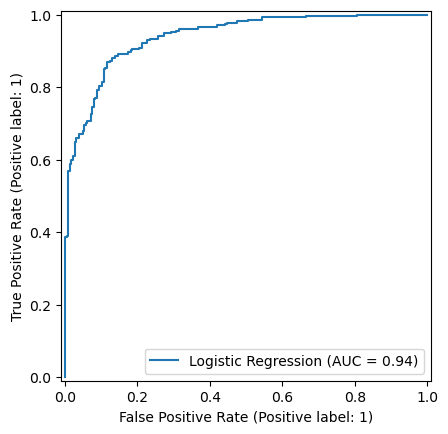

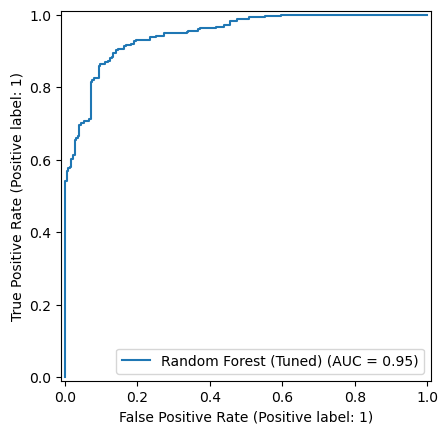

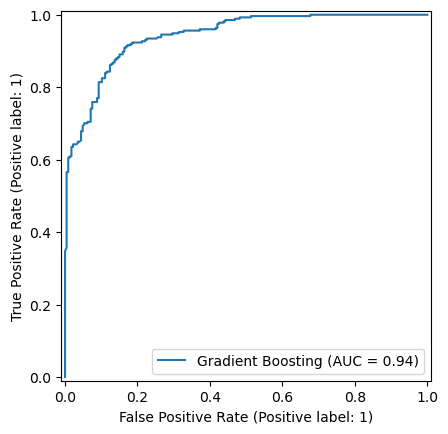

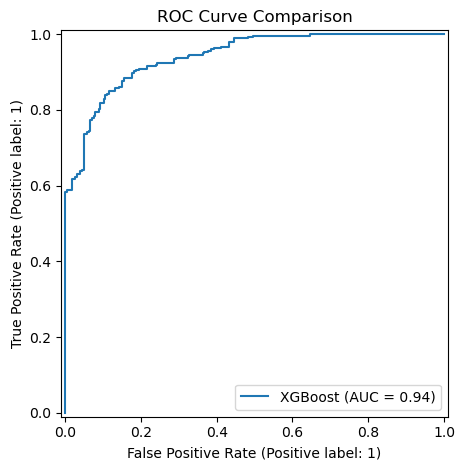

In [22]:
# Cell 11: ROC Curve Plot


plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_best_rf, name="Random Forest (Tuned)")
RocCurveDisplay.from_predictions(y_test, y_prob_gb, name="Gradient Boosting")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig(REPORTS_FIG / "advanced_model_comparison_roc.png", dpi=300, bbox_inches="tight")
plt.show()

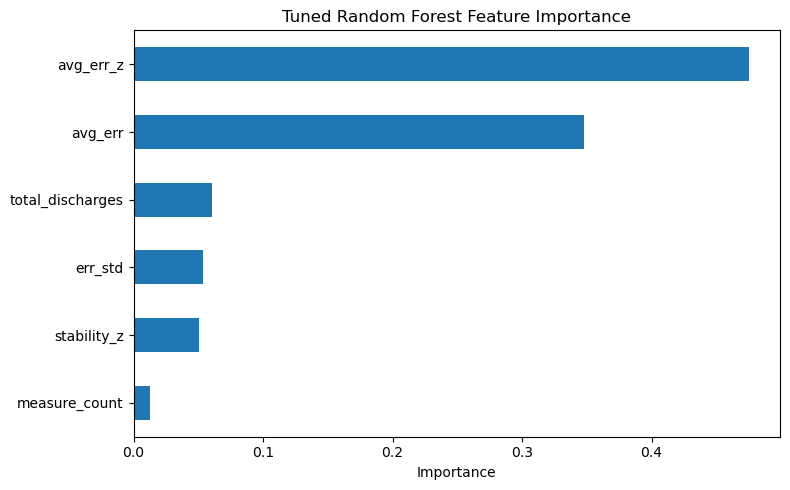

avg_err_z           0.4754
avg_err             0.3480
total_discharges    0.0605
err_std             0.0534
stability_z         0.0502
measure_count       0.0125
dtype: float64

SHAP could not be generated: No module named 'shap'


In [24]:
# Cell 12: Feature Importance and SHAP

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh")
plt.title("Tuned Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(REPORTS_FIG / "tuned_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

display(feature_importance.sort_values(ascending=False).round(4))

# Optional SHAP explanation
try:
    import shap

    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values[1], X_test, show=False)
    plt.tight_layout()
    plt.savefig(REPORTS_FIG / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("SHAP could not be generated:", e)

In [28]:
# Cell 13: Final Model Selection and Save


final_model = best_rf

print("Final model selected: Tuned Random Forest")
print("Reason: strongest cross-validation performance and lower variance")

joblib.dump(final_model, MODELS_DIR / "final_hospital_risk_model.pkl")
joblib.dump(X.columns.tolist(), MODELS_DIR / "model_features.pkl")

print("Saved model to:", MODELS_DIR / "final_hospital_risk_model.pkl")
print("Saved feature list to:", MODELS_DIR / "model_features.pkl")

Final model selected: Tuned Random Forest
Reason: strongest cross-validation performance and lower variance
Saved model to: C:\Users\jsrin\post_discharge_strategy\models\final_hospital_risk_model.pkl
Saved feature list to: C:\Users\jsrin\post_discharge_strategy\models\model_features.pkl


In [30]:
# Cell 14: Recommendation Logic


def generate_recommendations(row):
    recommendations = []

    if row["avg_err"] > 1.0:
        recommendations.append(
            "Reduce excess readmissions by improving discharge planning and post-discharge follow-up."
        )

    if row["err_std"] > 0.08:
        recommendations.append(
            "Standardize care processes across departments to reduce variability in readmission performance."
        )

    if row["measure_count"] < 4:
        recommendations.append(
            "Expand performance monitoring across more quality measures to improve coverage and insight."
        )

    if row["total_discharges"] > 10000:
        recommendations.append(
            "High discharge volume detected; strengthen care coordination and patient transition workflows."
        )

    if row["stability_z"] > 1.0:
        recommendations.append(
            "Monitor performance trends closely and investigate unstable readmission behavior over time."
        )

    if not recommendations:
        recommendations.append(
            "Current performance appears relatively stable. Continue monitoring and maintain existing interventions."
        )

    return recommendations

In [32]:
# Cell 15: Prediction with Recommendations


def predict_with_recommendation(model, input_df):
    prob = model.predict_proba(input_df)[0, 1]
    pred = model.predict(input_df)[0]
    recs = generate_recommendations(input_df.iloc[0])

    return {
        "risk_probability": float(prob),
        "risk_class": int(pred),
        "recommendations": recs
    }

In [34]:
# Cell 16: Test Sample Prediction + Recommendation


sample_input = X.iloc[[0]].copy()
display(sample_input)

result = predict_with_recommendation(final_model, sample_input)

print("Predicted probability of high risk:", round(result["risk_probability"], 4))
print("Predicted class:", result["risk_class"])

print("\nRecommendations:")
for rec in result["recommendations"]:
    print("-", rec)

,avg_err,avg_err_z,err_std,total_discharges,measure_count,stability_z
0,0.971467,-0.416945,0.045302,1748.0,6,-0.404628


Predicted probability of high risk: 0.035
Predicted class: 0

Recommendations:
- Current performance appears relatively stable. Continue monitoring and maintain existing interventions.
